In [1]:
# --- Install dependencies ---
!pip install -q mmh3

# --- Imports ---
import os
import json
import re
import time
import hashlib
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mmh3  # MurmurHash — fast, deterministic hashing

# For reproducibility
np.random.seed(42)


In [2]:
# ============================================================
# GLOBAL CONFIGURATION
# Change these parameters to control the pipeline
# ============================================================

# Data loading
SAMPLE_SIZE = 10_000          # Number of documents to load (set higher for final run, e.g. 50_000)
CATEGORY_FILTER = "cs."       # Filter by category prefix (e.g. "cs." for Computer Science, None for all)
MIN_ABSTRACT_LEN = 150        # Minimum abstract length in characters (filters out withdrawn/stubs)

# Shingling
SHINGLE_TYPE = "word"         # "word" or "char"
K_SHINGLE = 3                 # Shingle size (3 for word shingles, 5-9 for char shingles)

# MinHash
NUM_HASHES = 100              # Number of hash functions for MinHash signatures

# LSH
NUM_BANDS = 20                # Number of bands (NUM_BANDS * ROWS_PER_BAND must equal NUM_HASHES)
ROWS_PER_BAND = 5             # Rows per band

# Similarity threshold for final filtering
SIMILARITY_THRESHOLD = 0.5    # Minimum Jaccard similarity to report

assert NUM_BANDS * ROWS_PER_BAND == NUM_HASHES, \
    f"NUM_BANDS ({NUM_BANDS}) * ROWS_PER_BAND ({ROWS_PER_BAND}) must equal NUM_HASHES ({NUM_HASHES})"

approx_threshold = (1 / NUM_BANDS) ** (1 / ROWS_PER_BAND)
print(f"Configuration summary:")
print(f"  Sample size:          {SAMPLE_SIZE:,}")
print(f"  Category filter:      {CATEGORY_FILTER}")
print(f"  Min abstract length:  {MIN_ABSTRACT_LEN} chars")
print(f"  Shingle type:         {SHINGLE_TYPE} (k={K_SHINGLE})")
print(f"  MinHash functions:    {NUM_HASHES}")
print(f"  LSH bands x rows:    {NUM_BANDS} x {ROWS_PER_BAND}")
print(f"  Approx LSH threshold: {approx_threshold:.3f}")
print(f"  Final sim threshold:  {SIMILARITY_THRESHOLD}")


Configuration summary:
  Sample size:          10,000
  Category filter:      cs.
  Min abstract length:  150 chars
  Shingle type:         word (k=3)
  MinHash functions:    100
  LSH bands x rows:    20 x 5
  Approx LSH threshold: 0.549
  Final sim threshold:  0.5


In [3]:
# --- Download dataset from Kaggle ---
os.environ['KAGGLE_USERNAME'] = "xxxxxx"
os.environ['KAGGLE_KEY'] = "xxxxxx"

!kaggle datasets download -d Cornell-University/arxiv
!unzip -o arxiv.zip -d arxiv_data/


Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
 99% 1.57G/1.58G [00:23<00:00, 81.4MB/s]
100% 1.58G/1.58G [00:23<00:00, 71.6MB/s]
Archive:  arxiv.zip
  inflating: arxiv_data/arxiv-metadata-oai-snapshot.json  


In [4]:
# --- Load data incrementally ---
# Boilerplate phrases that indicate withdrawn/placeholder abstracts
WITHDRAWN_KEYWORDS = [
    "withdrawn", "this article has been removed",
    "this submission has been withdrawn", "paper has been removed"
]

def load_arxiv_data(filepath, sample_size=SAMPLE_SIZE,
                    category_filter=CATEGORY_FILTER,
                    min_abstract_len=MIN_ABSTRACT_LEN):
    """
    Load arXiv metadata line by line, filtering by category and quality.

    Filters applied:
    - Category prefix filter (e.g., 'cs.' for Computer Science)
    - Minimum abstract length to remove stubs
    - Withdrawn/removed paper detection
    """
    docs = []
    total_scanned = 0
    skipped_short = 0
    skipped_withdrawn = 0

    with open(filepath, 'r') as f:
        for line in f:
            if len(docs) >= sample_size:
                break
            total_scanned += 1
            paper = json.loads(line)

            # Optional category filtering
            if category_filter and not any(
                cat.startswith(category_filter)
                for cat in paper.get('categories', '').split()
            ):
                continue

            abstract = paper.get('abstract', '').strip()

            # Filter: minimum length
            if len(abstract) < min_abstract_len:
                skipped_short += 1
                continue

            # Filter: withdrawn papers
            abstract_lower = abstract.lower()
            if any(kw in abstract_lower for kw in WITHDRAWN_KEYWORDS):
                skipped_withdrawn += 1
                continue

            docs.append({
                'id': paper['id'],
                'title': paper.get('title', '').strip(),
                'abstract': abstract,
                'categories': paper.get('categories', ''),
            })

    print(f"Scanned {total_scanned:,} papers total")
    print(f"  Loaded:              {len(docs):,} documents")
    print(f"  Skipped (too short): {skipped_short:,}")
    print(f"  Skipped (withdrawn): {skipped_withdrawn:,}")
    if category_filter:
        print(f"  Category filter:     '{category_filter}'")
    return docs

# Load data
DATA_PATH = "arxiv_data/arxiv-metadata-oai-snapshot.json"
docs = load_arxiv_data(DATA_PATH)


Scanned 158,241 papers total
  Loaded:              10,000 documents
  Skipped (too short): 140
  Skipped (withdrawn): 8
  Category filter:     'cs.'


Dataset shape: (10000, 4)

Sample entry:
  ID:         0704.0002
  Title:      Sparsity-certifying Graph Decompositions...
  Abstract:   We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and use
it obtain a characterization of the family of $(k,\ell)$-sparse graphs and
algorithmic solutions to a family of problems co...
  Categories: math.CO cs.CG

Abstract length statistics:
count    10000.000000
mean       890.216500
std        379.955657
min        150.000000
25%        602.000000
50%        854.000000
75%       1147.000000
max       1913.000000
Name: abstract, dtype: float64


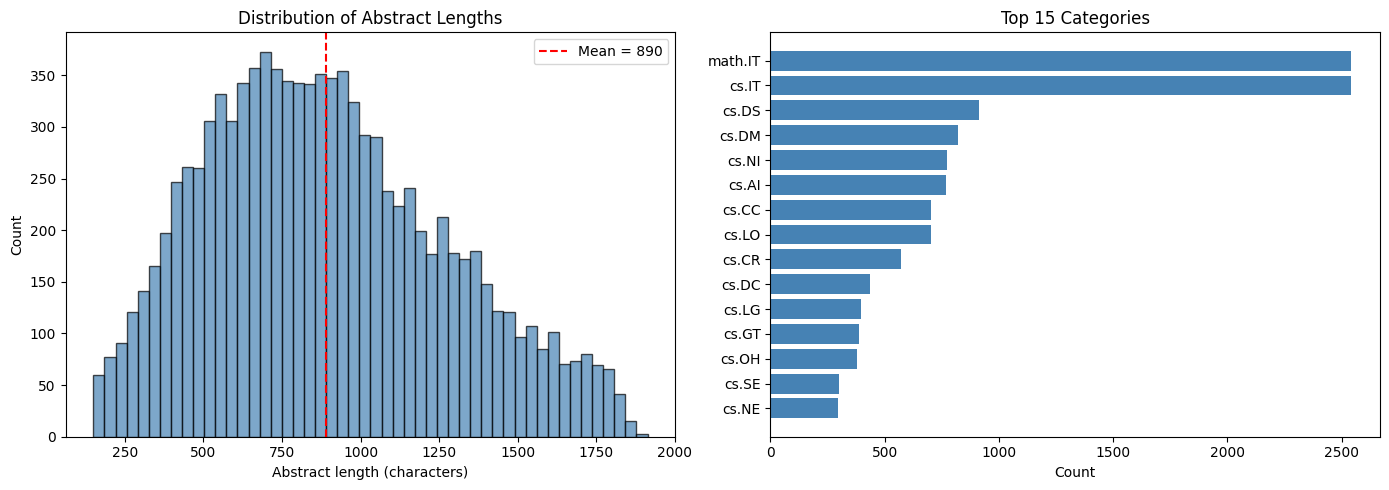

In [5]:
# --- Basic exploration ---
df = pd.DataFrame(docs)
print(f"Dataset shape: {df.shape}")
print(f"\nSample entry:")
print(f"  ID:         {docs[0]['id']}")
print(f"  Title:      {docs[0]['title'][:80]}...")
print(f"  Abstract:   {docs[0]['abstract'][:200]}...")
print(f"  Categories: {docs[0]['categories']}")

# Abstract length distribution
abstract_lengths = df['abstract'].str.len()
print(f"\nAbstract length statistics:")
print(abstract_lengths.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(abstract_lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Abstract length (characters)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Abstract Lengths')
axes[0].axvline(x=abstract_lengths.mean(), color='red', linestyle='--',
                label=f'Mean = {abstract_lengths.mean():.0f}')
axes[0].legend()

# Category distribution (top 15)
all_cats = df['categories'].str.split().explode()
top_cats = all_cats.value_counts().head(15)
axes[1].barh(range(len(top_cats)), top_cats.values, color='steelblue')
axes[1].set_yticks(range(len(top_cats)))
axes[1].set_yticklabels(top_cats.index)
axes[1].set_xlabel('Count')
axes[1].set_title('Top 15 Categories')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [6]:
def preprocess_abstract(text):
    """
    Clean an abstract text:
    - Remove LaTeX math commands and common markup
    - Convert to lowercase
    - Remove special characters (keep only alphanumeric and spaces)
    - Normalize whitespace
    """
    # Remove LaTeX inline math ($...$)
    text = re.sub(r'\$[^$]*\$', ' ', text)
    # Remove LaTeX commands like \textbf{}, \emph{}, \cite{}, etc.
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)
    # Remove remaining LaTeX commands (\alpha, \beta, etc.)
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)
    # Remove curly braces
    text = re.sub(r'[{}]', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Keep only alphanumeric and spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
for doc in docs:
    doc['clean_abstract'] = preprocess_abstract(doc['abstract'])

# Show examples
print("=== Before preprocessing ===")
print(docs[0]['abstract'][:300])
print("\n=== After preprocessing ===")
print(docs[0]['clean_abstract'][:300])


=== Before preprocessing ===
We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and use
it obtain a characterization of the family of $(k,\ell)$-sparse graphs and
algorithmic solutions to a family of problems concerning tree decompositions of
graphs. Special instances of sparse graphs appear in rigidity theory

=== After preprocessing ===
we describe a new algorithm the pebble game with colors and use it obtain a characterization of the family of sparse graphs and algorithmic solutions to a family of problems concerning tree decompositions of graphs special instances of sparse graphs appear in rigidity theory and have received increa


In [7]:
def create_shingles(text, k=K_SHINGLE, shingle_type=SHINGLE_TYPE):
    """
    Create a set of hashed k-shingles from text.

    Args:
        text: Cleaned text string
        k: Shingle size
        shingle_type: 'word' for word-level, 'char' for character-level

    Returns:
        Set of integer hashes representing shingles
    """
    if shingle_type == "word":
        tokens = text.split()
        if len(tokens) < k:
            return set()
        shingles = {' '.join(tokens[i:i+k]) for i in range(len(tokens) - k + 1)}
    elif shingle_type == "char":
        if len(text) < k:
            return set()
        shingles = {text[i:i+k] for i in range(len(text) - k + 1)}
    else:
        raise ValueError(f"Unknown shingle_type: {shingle_type}")

    # Hash shingles to integers using MurmurHash for compactness
    hashed_shingles = {mmh3.hash(s, seed=0) & 0xFFFFFFFF for s in shingles}
    return hashed_shingles

# Create shingle sets for all documents
print(f"Creating {SHINGLE_TYPE} {K_SHINGLE}-shingles for {len(docs):,} documents...")
t0 = time.time()

shingle_sets = []
for doc in docs:
    shingles = create_shingles(doc['clean_abstract'])
    shingle_sets.append(shingles)

elapsed = time.time() - t0
print(f"Shingling completed in {elapsed:.2f}s")

# Statistics
shingle_sizes = [len(s) for s in shingle_sets]
print(f"\nShingle set size statistics:")
print(f"  Mean:   {np.mean(shingle_sizes):.1f}")
print(f"  Median: {np.median(shingle_sizes):.1f}")
print(f"  Min:    {np.min(shingle_sizes)}")
print(f"  Max:    {np.max(shingle_sizes)}")

# Remove documents with empty shingle sets
valid_indices = [i for i, s in enumerate(shingle_sets) if len(s) > 0]
if len(valid_indices) < len(docs):
    print(f"\nRemoved {len(docs) - len(valid_indices)} documents with empty shingle sets")
    docs = [docs[i] for i in valid_indices]
    shingle_sets = [shingle_sets[i] for i in valid_indices]
print(f"Final document count: {len(docs):,}")


Creating word 3-shingles for 10,000 documents...
Shingling completed in 1.99s

Shingle set size statistics:
  Mean:   131.2
  Median: 125.0
  Min:    11
  Max:    322
Final document count: 10,000


In [8]:
# --- Quick sanity check: Jaccard similarity between first few docs ---
def jaccard_similarity(set_a, set_b):
    """Compute exact Jaccard similarity between two sets."""
    if not set_a or not set_b:
        return 0.0
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0

# Show a few pairwise similarities
print("Pairwise Jaccard similarities (first 10 documents, showing J > 0.05):")
found_any = False
for i in range(min(10, len(docs))):
    for j in range(i + 1, min(10, len(docs))):
        sim = jaccard_similarity(shingle_sets[i], shingle_sets[j])
        if sim > 0.05:
            found_any = True
            print(f"  docs[{i}] vs docs[{j}]: J = {sim:.4f}")
            print(f"    [{docs[i]['title'][:70]}]")
            print(f"    [{docs[j]['title'][:70]}]")
if not found_any:
    print("  (No pairs with J > 0.05 among first 10 docs — expected for diverse topics)")


Pairwise Jaccard similarities (first 10 documents, showing J > 0.05):
  docs[2] vs docs[3]: J = 0.1053
    [Intelligent location of simultaneously active acoustic emission source]
    [Intelligent location of simultaneously active acoustic emission source]


In [9]:
# --- Generate hash function parameters ---
LARGE_PRIME = 4294967311  # A prime larger than 2^32

# Generate random coefficients for each hash function
a_coeffs = np.random.randint(1, LARGE_PRIME, size=NUM_HASHES, dtype=np.int64)
b_coeffs = np.random.randint(0, LARGE_PRIME, size=NUM_HASHES, dtype=np.int64)

def compute_minhash_signature(shingle_set, a=a_coeffs, b=b_coeffs, p=LARGE_PRIME):
    """
    Compute MinHash signature for a single document's shingle set.

    For each hash function h_i, the signature value is:
        sig[i] = min over all shingles s of: (a[i]*s + b[i]) % p

    Returns:
        numpy array of shape (NUM_HASHES,) with the signature
    """
    signature = np.full(NUM_HASHES, np.inf)

    for shingle in shingle_set:
        # Compute all hash values for this shingle at once (vectorized)
        hash_values = (a * shingle + b) % p
        # Update signature with element-wise minimum
        signature = np.minimum(signature, hash_values)

    return signature.astype(np.int64)

# --- Compute signatures for all documents ---
print(f"Computing MinHash signatures ({NUM_HASHES} hash functions) for {len(docs):,} documents...")
t0 = time.time()

signatures = np.zeros((len(docs), NUM_HASHES), dtype=np.int64)
for idx, shingles in enumerate(shingle_sets):
    signatures[idx] = compute_minhash_signature(shingles)
    if (idx + 1) % 2000 == 0:
        print(f"  Processed {idx + 1:,}/{len(docs):,} documents...")

elapsed = time.time() - t0
print(f"MinHash computation completed in {elapsed:.2f}s")
print(f"Signature matrix shape: {signatures.shape}")


Computing MinHash signatures (100 hash functions) for 10,000 documents...
  Processed 2,000/10,000 documents...
  Processed 4,000/10,000 documents...
  Processed 6,000/10,000 documents...
  Processed 8,000/10,000 documents...
  Processed 10,000/10,000 documents...
MinHash computation completed in 7.66s
Signature matrix shape: (10000, 100)


Validating MinHash approximation...
  Total validation pairs: 200
  Mean Absolute Error:    0.0189
  Max Absolute Error:     0.1332


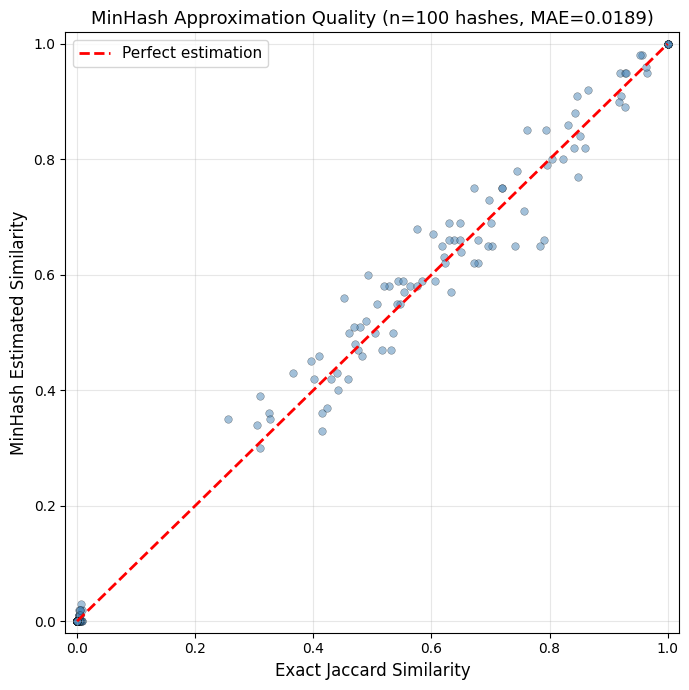

In [10]:
# --- Validate MinHash approximation ---
# Strategy: sample pairs from different similarity ranges for a comprehensive validation
# We first compute some candidate pairs via a quick LSH pass, then mix with random pairs

print("Validating MinHash approximation...")

# Step 1: Get some high-similarity pairs via a preliminary LSH scan
# (We'll define LSH properly later; here we use a quick version)
quick_candidates = set()
for band_idx in range(NUM_BANDS):
    start = band_idx * ROWS_PER_BAND
    end = start + ROWS_PER_BAND
    band = signatures[:, start:end]
    buckets = defaultdict(list)
    for doc_idx in range(len(docs)):
        bucket_id = hash(tuple(band[doc_idx]))
        buckets[bucket_id].append(doc_idx)
    for bucket, doc_indices in buckets.items():
        if 1 < len(doc_indices) <= 50:  # Skip very large buckets
            for ii in range(len(doc_indices)):
                for jj in range(ii+1, len(doc_indices)):
                    quick_candidates.add(
                        (min(doc_indices[ii], doc_indices[jj]),
                         max(doc_indices[ii], doc_indices[jj]))
                    )

# Step 2: Mix candidate pairs (likely high similarity) with random pairs (likely low similarity)
validation_pairs = []

# Add candidate pairs (up to 100)
cand_list = list(quick_candidates)
np.random.shuffle(cand_list)
for i, j in cand_list[:100]:
    exact_j = jaccard_similarity(shingle_sets[i], shingle_sets[j])
    estimated_j = np.mean(signatures[i] == signatures[j])
    validation_pairs.append((exact_j, estimated_j))

# Add random pairs (100)
for _ in range(100):
    i, j = np.random.choice(len(docs), 2, replace=False)
    exact_j = jaccard_similarity(shingle_sets[i], shingle_sets[j])
    estimated_j = np.mean(signatures[i] == signatures[j])
    validation_pairs.append((exact_j, estimated_j))

exact_vals = np.array([p[0] for p in validation_pairs])
estimated_vals = np.array([p[1] for p in validation_pairs])
mae = np.mean(np.abs(exact_vals - estimated_vals))

print(f"  Total validation pairs: {len(validation_pairs)}")
print(f"  Mean Absolute Error:    {mae:.4f}")
print(f"  Max Absolute Error:     {np.max(np.abs(exact_vals - estimated_vals)):.4f}")

plt.figure(figsize=(7, 7))
plt.scatter(exact_vals, estimated_vals, alpha=0.5, s=30, c='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect estimation')
plt.xlabel('Exact Jaccard Similarity', fontsize=12)
plt.ylabel('MinHash Estimated Similarity', fontsize=12)
plt.title(f'MinHash Approximation Quality (n={NUM_HASHES} hashes, MAE={mae:.4f})', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()


In [11]:
def lsh_find_candidates(signatures, num_bands=NUM_BANDS, rows_per_band=ROWS_PER_BAND):
    """
    Apply LSH banding technique to find candidate similar pairs.

    Args:
        signatures: numpy array of shape (n_docs, num_hashes)
        num_bands: number of bands
        rows_per_band: rows per band

    Returns:
        Set of candidate pairs (i, j) where i < j
    """
    n_docs = signatures.shape[0]
    candidate_pairs = set()

    for band_idx in range(num_bands):
        # Extract the band's portion of each signature
        start = band_idx * rows_per_band
        end = start + rows_per_band
        band = signatures[:, start:end]

        # Hash each document's band portion into buckets
        buckets = defaultdict(list)
        for doc_idx in range(n_docs):
            # Create a hashable key from the band values
            band_key = tuple(band[doc_idx])
            bucket_id = hash(band_key)
            buckets[bucket_id].append(doc_idx)

        # All pairs in the same bucket are candidate pairs
        for bucket, doc_indices in buckets.items():
            if len(doc_indices) > 1:
                for i in range(len(doc_indices)):
                    for j in range(i + 1, len(doc_indices)):
                        pair = (min(doc_indices[i], doc_indices[j]),
                                max(doc_indices[i], doc_indices[j]))
                        candidate_pairs.add(pair)

    return candidate_pairs

# --- Run LSH ---
print(f"Running LSH ({NUM_BANDS} bands x {ROWS_PER_BAND} rows)...")
t0 = time.time()

candidate_pairs = lsh_find_candidates(signatures)

elapsed = time.time() - t0
total_possible = len(docs) * (len(docs) - 1) // 2
print(f"LSH completed in {elapsed:.2f}s")
print(f"  Candidate pairs found: {len(candidate_pairs):,}")
print(f"  Total possible pairs:  {total_possible:,}")
print(f"  Reduction ratio:       {len(candidate_pairs)/total_possible*100:.4f}%")
print(f"  Speedup factor:        {total_possible/max(1,len(candidate_pairs)):.0f}x fewer comparisons")


Running LSH (20 bands x 5 rows)...
LSH completed in 4.23s
  Candidate pairs found: 144
  Total possible pairs:  49,995,000
  Reduction ratio:       0.0003%
  Speedup factor:        347188x fewer comparisons


In [12]:
# --- Verify candidates: compute exact Jaccard for each candidate pair ---
print(f"Verifying {len(candidate_pairs):,} candidate pairs...")
t0 = time.time()

similar_pairs = []
all_candidate_sims = []  # Store all candidate similarities for analysis

for i, j in candidate_pairs:
    exact_sim = jaccard_similarity(shingle_sets[i], shingle_sets[j])
    all_candidate_sims.append(exact_sim)
    if exact_sim >= SIMILARITY_THRESHOLD:
        similar_pairs.append((i, j, exact_sim))

elapsed = time.time() - t0
print(f"Verification completed in {elapsed:.2f}s")
print(f"  Pairs above threshold ({SIMILARITY_THRESHOLD}): {len(similar_pairs):,}")
print(f"  Pairs below threshold (false positives):  {len(candidate_pairs) - len(similar_pairs):,}")
print(f"  False positive rate: {(1 - len(similar_pairs)/max(1, len(candidate_pairs)))*100:.1f}%")

# Sort by similarity (descending)
similar_pairs.sort(key=lambda x: x[2], reverse=True)


Verifying 144 candidate pairs...
Verification completed in 0.01s
  Pairs above threshold (0.5): 107
  Pairs below threshold (false positives):  37
  False positive rate: 25.7%


In [13]:
# --- Display top similar pairs ---
print(f"{'='*90}")
print(f"TOP 10 MOST SIMILAR ABSTRACT PAIRS")
print(f"{'='*90}")

for rank, (i, j, sim) in enumerate(similar_pairs[:10], 1):
    print(f"\n--- Pair {rank} (Jaccard = {sim:.4f}) ---")
    print(f"  Paper A [{docs[i]['id']}]: {docs[i]['title'][:80]}")
    print(f"  Paper B [{docs[j]['id']}]: {docs[j]['title'][:80]}")
    print(f"  Categories A: {docs[i]['categories']}")
    print(f"  Categories B: {docs[j]['categories']}")
    print(f"  Abstract A: {docs[i]['clean_abstract'][:150]}...")
    print(f"  Abstract B: {docs[j]['clean_abstract'][:150]}...")


TOP 10 MOST SIMILAR ABSTRACT PAIRS

--- Pair 1 (Jaccard = 1.0000) ---
  Paper A [0807.4671]: Codes Associated with $O^+(2n,2^r)$ and Power Moments of Kloosterman
  Sums
  Paper B [0808.3003]: Codes Associated with Orthogonal Groups and Power Moments of Kloosterman
  Sums
  Categories A: math.NT cs.IT math.IT
  Categories B: math.NT cs.IT math.IT
  Abstract A: in this paper we construct three binary linear codes respectively associated with the orthogonal groups with powers of two then we obtain recursive fo...
  Abstract B: in this paper we construct three binary linear codes respectively associated with the orthogonal groups with powers of two then we obtain recursive fo...

--- Pair 2 (Jaccard = 1.0000) ---
  Paper A [0802.2773]: Stiffness Analysis of 3-d.o.f. Overconstrained Translational Parallel
  Manipula
  Paper B [0811.3536]: Analyse de la rigidit\'e des machines outils 3 axes d'architecture
  parall\`ele
  Categories A: cs.RO physics.class-ph
  Categories B: cs.RO
  Abstract A

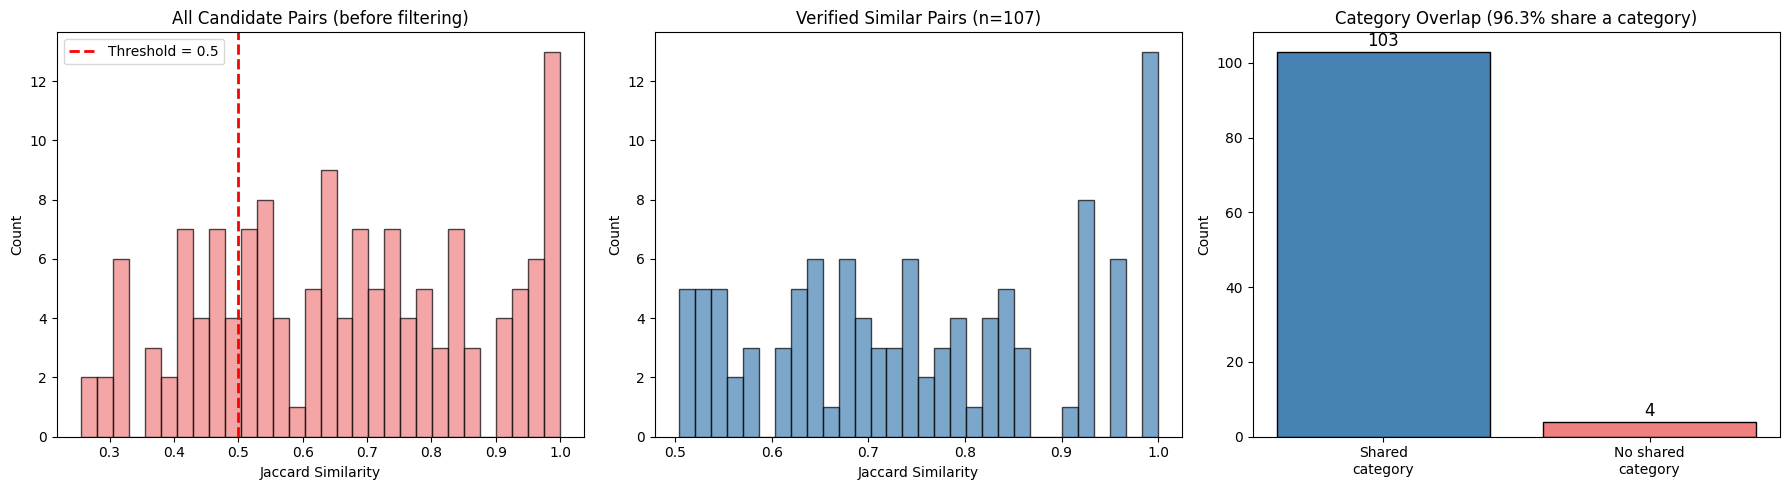

In [14]:
# --- Detailed analysis of results ---
if similar_pairs:
    similarities = [s for _, _, s in similar_pairs]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Distribution of all candidate pair similarities (before threshold)
    axes[0].hist(all_candidate_sims, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
    axes[0].axvline(x=SIMILARITY_THRESHOLD, color='red', linestyle='--', linewidth=2,
                    label=f'Threshold = {SIMILARITY_THRESHOLD}')
    axes[0].set_xlabel('Jaccard Similarity')
    axes[0].set_ylabel('Count')
    axes[0].set_title('All Candidate Pairs (before filtering)')
    axes[0].legend()

    # Plot 2: Distribution of verified similar pairs (after threshold)
    axes[1].hist(similarities, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].set_xlabel('Jaccard Similarity')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Verified Similar Pairs (n={len(similar_pairs)})')

    # Plot 3: Category overlap analysis
    same_cat_count = 0
    for i, j, sim in similar_pairs:
        cats_i = set(docs[i]['categories'].split())
        cats_j = set(docs[j]['categories'].split())
        if cats_i & cats_j:
            same_cat_count += 1

    overlap_pct = same_cat_count / len(similar_pairs) * 100
    bars = axes[2].bar(['Shared\ncategory', 'No shared\ncategory'],
                       [same_cat_count, len(similar_pairs) - same_cat_count],
                       color=['steelblue', 'lightcoral'], edgecolor='black')
    axes[2].set_title(f'Category Overlap ({overlap_pct:.1f}% share a category)')
    axes[2].set_ylabel('Count')
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                     f'{int(height)}', ha='center', va='bottom', fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("No similar pairs found. Try lowering SIMILARITY_THRESHOLD or increasing SAMPLE_SIZE.")


In [15]:
def run_pipeline(sub_shingles, n_hashes=NUM_HASHES, n_bands=NUM_BANDS,
                 rows=ROWS_PER_BAND, threshold=SIMILARITY_THRESHOLD):
    """
    Run the full pipeline on given shingle sets and return timing for each stage.
    """
    timings = {}
    n = len(sub_shingles)

    # MinHash
    t0 = time.time()
    sigs = np.zeros((n, n_hashes), dtype=np.int64)
    for idx, shingles in enumerate(sub_shingles):
        sigs[idx] = compute_minhash_signature(shingles)
    timings['minhash'] = time.time() - t0

    # LSH
    t0 = time.time()
    candidates = lsh_find_candidates(sigs, n_bands, rows)
    timings['lsh'] = time.time() - t0

    # Verification
    t0 = time.time()
    verified = []
    for i, j in candidates:
        sim = jaccard_similarity(sub_shingles[i], sub_shingles[j])
        if sim >= threshold:
            verified.append((i, j, sim))
    timings['verification'] = time.time() - t0

    timings['total'] = timings['minhash'] + timings['lsh'] + timings['verification']
    timings['n_candidates'] = len(candidates)
    timings['n_similar'] = len(verified)
    timings['verified_pairs'] = set((i, j) for i, j, _ in verified)

    return timings

def brute_force_similar(sub_shingles, threshold=SIMILARITY_THRESHOLD):
    """Find all similar pairs by comparing every pair. O(n^2)."""
    t0 = time.time()
    n = len(sub_shingles)
    results = []
    for i in range(n):
        for j in range(i + 1, n):
            sim = jaccard_similarity(sub_shingles[i], sub_shingles[j])
            if sim >= threshold:
                results.append((i, j, sim))
    elapsed = time.time() - t0
    return elapsed, results


In [16]:
# --- Scalability experiment ---
test_sizes = [500, 1000, 2000, 5000]
if len(docs) >= 10000:
    test_sizes.append(10000)
if len(docs) >= 20000:
    test_sizes.append(20000)

# Only run brute-force for small sizes (it's O(n^2))
BRUTE_FORCE_MAX = 5000

lsh_timings = []
bf_timings = []
recall_data = []

for n in test_sizes:
    if n > len(docs):
        break
    print(f"\nTesting with n = {n:,}...")

    sub_shingles = shingle_sets[:n]

    # LSH pipeline
    t = run_pipeline(sub_shingles)
    lsh_timings.append({'n': n, **t})
    print(f"  LSH:         {t['total']:.2f}s  (candidates: {t['n_candidates']:,}, verified: {t['n_similar']:,})")

    # Brute-force (only for small n)
    if n <= BRUTE_FORCE_MAX:
        bf_time, bf_results = brute_force_similar(sub_shingles)
        bf_pairs = set((i, j) for i, j, _ in bf_results)
        bf_timings.append({'n': n, 'time': bf_time, 'n_similar': len(bf_results)})
        print(f"  Brute-force: {bf_time:.2f}s  (similar: {len(bf_results):,})")

        # Compute recall: what fraction of brute-force pairs did LSH find?
        if len(bf_pairs) > 0:
            found_by_lsh = len(t['verified_pairs'] & bf_pairs)
            recall = found_by_lsh / len(bf_pairs)
            recall_data.append({'n': n, 'recall': recall,
                                'found': found_by_lsh, 'total': len(bf_pairs)})
            print(f"  Recall:      {recall:.2%}  ({found_by_lsh}/{len(bf_pairs)} pairs)")
        else:
            print(f"  Recall:      N/A (no similar pairs in brute-force)")

print("\nScalability experiment complete.")



Testing with n = 500...
  LSH:         0.80s  (candidates: 4, verified: 3)
  Brute-force: 2.01s  (similar: 4)
  Recall:      75.00%  (3/4 pairs)

Testing with n = 1,000...
  LSH:         0.81s  (candidates: 18, verified: 16)
  Brute-force: 9.05s  (similar: 17)
  Recall:      94.12%  (16/17 pairs)

Testing with n = 2,000...
  LSH:         2.78s  (candidates: 31, verified: 28)
  Brute-force: 34.46s  (similar: 30)
  Recall:      93.33%  (28/30 pairs)

Testing with n = 5,000...
  LSH:         4.39s  (candidates: 61, verified: 48)
  Brute-force: 217.78s  (similar: 52)
  Recall:      92.31%  (48/52 pairs)

Testing with n = 10,000...
  LSH:         12.63s  (candidates: 144, verified: 107)

Scalability experiment complete.


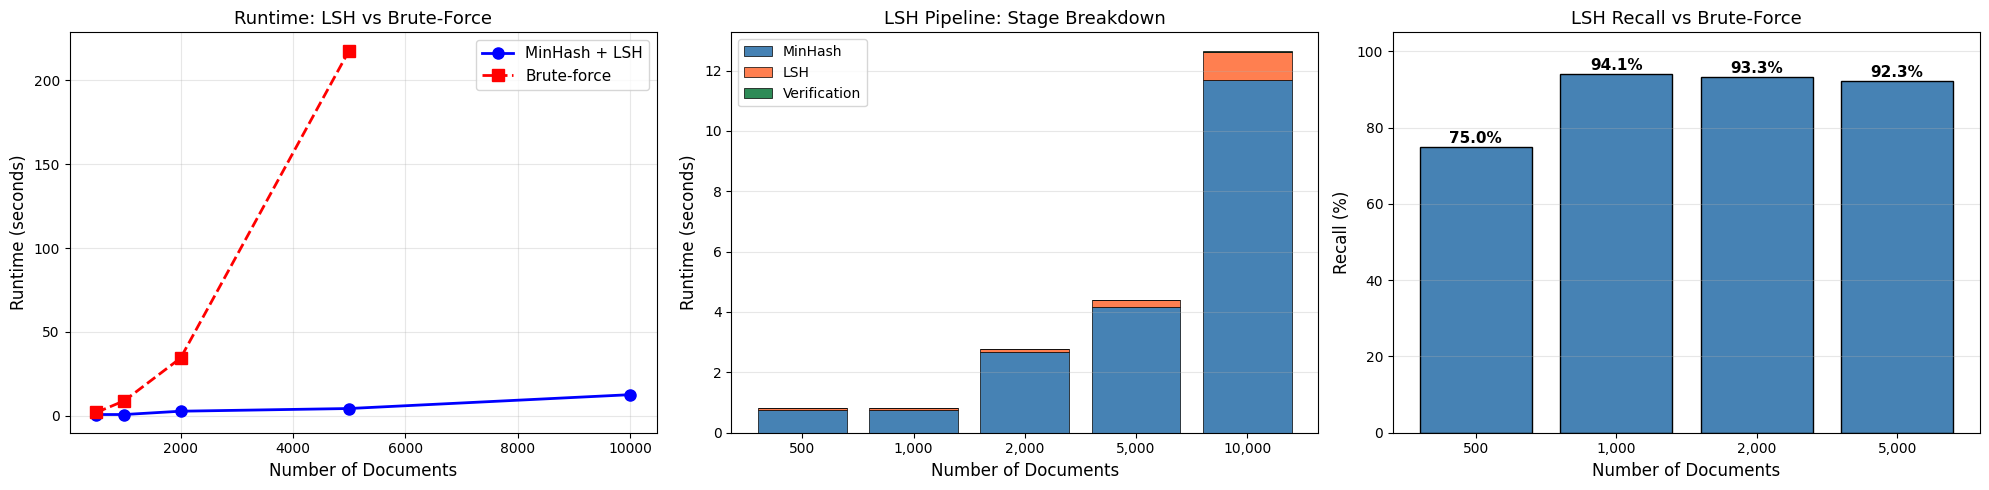


       n |    LSH (s) |     BF (s) |    Speedup |  LSH pairs |   Recall
-------------------------------------------------------------------------------------
     500 |       0.80 |       2.01 |       2.5x |          3 |    75.0%
   1,000 |       0.81 |       9.05 |      11.2x |         16 |    94.1%
   2,000 |       2.78 |      34.46 |      12.4x |         28 |    93.3%
   5,000 |       4.39 |     217.78 |      49.6x |         48 |    92.3%
  10,000 |      12.63 |          — |          — |        107 |        —


In [17]:
# --- Plot scalability results ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Runtime comparison (LSH vs Brute-Force)
lsh_ns = [t['n'] for t in lsh_timings]
lsh_times = [t['total'] for t in lsh_timings]
axes[0].plot(lsh_ns, lsh_times, 'bo-', label='MinHash + LSH', linewidth=2, markersize=8)

if bf_timings:
    bf_ns = [t['n'] for t in bf_timings]
    bf_times_list = [t['time'] for t in bf_timings]
    axes[0].plot(bf_ns, bf_times_list, 'rs--', label='Brute-force', linewidth=2, markersize=8)

axes[0].set_xlabel('Number of Documents', fontsize=12)
axes[0].set_ylabel('Runtime (seconds)', fontsize=12)
axes[0].set_title('Runtime: LSH vs Brute-Force', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: LSH stage breakdown (stacked bar)
stages = ['minhash', 'lsh', 'verification']
stage_labels = ['MinHash', 'LSH', 'Verification']
colors = ['steelblue', 'coral', 'seagreen']
bottom = np.zeros(len(lsh_timings))

for stage, label, color in zip(stages, stage_labels, colors):
    values = [t[stage] for t in lsh_timings]
    axes[1].bar(range(len(lsh_timings)), values, bottom=bottom, label=label,
                color=color, edgecolor='black', linewidth=0.5)
    bottom += np.array(values)

axes[1].set_xticks(range(len(lsh_timings)))
axes[1].set_xticklabels([f"{t['n']:,}" for t in lsh_timings], fontsize=10)
axes[1].set_xlabel('Number of Documents', fontsize=12)
axes[1].set_ylabel('Runtime (seconds)', fontsize=12)
axes[1].set_title('LSH Pipeline: Stage Breakdown', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Recall analysis
if recall_data:
    rec_ns = [r['n'] for r in recall_data]
    rec_vals = [r['recall'] * 100 for r in recall_data]
    axes[2].bar(range(len(recall_data)), rec_vals, color='steelblue', edgecolor='black')
    axes[2].set_xticks(range(len(recall_data)))
    axes[2].set_xticklabels([f"{r['n']:,}" for r in recall_data], fontsize=10)
    axes[2].set_xlabel('Number of Documents', fontsize=12)
    axes[2].set_ylabel('Recall (%)', fontsize=12)
    axes[2].set_title('LSH Recall vs Brute-Force', fontsize=13)
    axes[2].set_ylim(0, 105)
    axes[2].grid(True, alpha=0.3, axis='y')
    # Add percentage labels on bars
    for idx, val in enumerate(rec_vals):
        axes[2].text(idx, val + 1, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'No recall data\n(increase BRUTE_FORCE_MAX)',
                 ha='center', va='center', transform=axes[2].transAxes, fontsize=12)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*85)
print(f"{'n':>8} | {'LSH (s)':>10} | {'BF (s)':>10} | {'Speedup':>10} | {'LSH pairs':>10} | {'Recall':>8}")
print("-"*85)
for lt in lsh_timings:
    bf_match = next((b for b in bf_timings if b['n'] == lt['n']), None)
    bf_str = f"{bf_match['time']:.2f}" if bf_match else "—"
    speedup = f"{bf_match['time']/lt['total']:.1f}x" if bf_match else "—"
    rec_match = next((r for r in recall_data if r['n'] == lt['n']), None)
    rec_str = f"{rec_match['recall']:.1%}" if rec_match else "—"
    print(f"{lt['n']:>8,} | {lt['total']:>10.2f} | {bf_str:>10} | {speedup:>10} | {lt['n_similar']:>10,} | {rec_str:>8}")


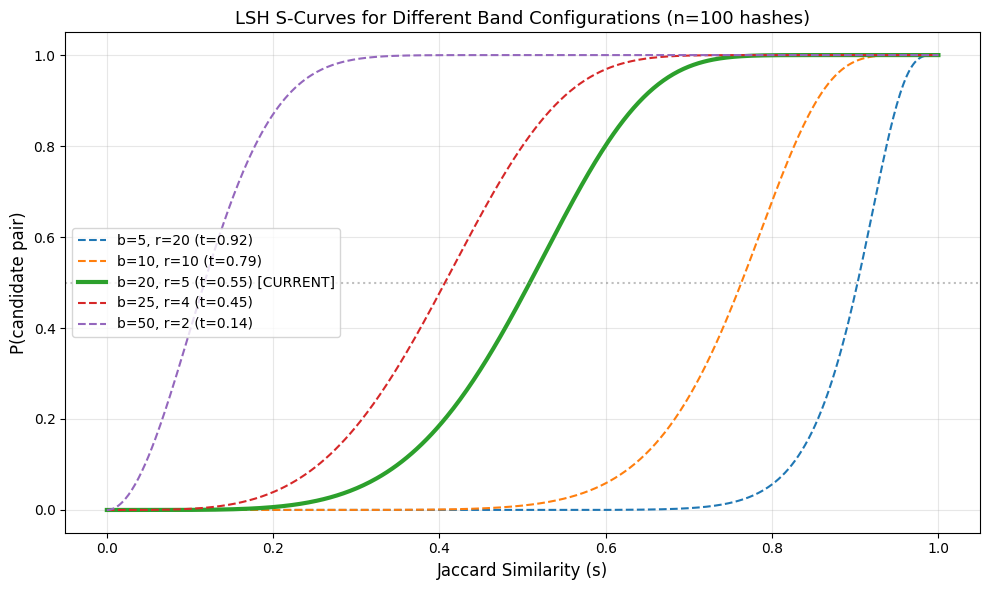

Configuration summary:
   Bands |   Rows |  Threshold
  ----------------------------
       5 |     20 |      0.923
      10 |     10 |      0.794
      20 |      5 |      0.549 <-- current
      25 |      4 |      0.447
      50 |      2 |      0.141


In [18]:
# --- Theoretical S-curves ---
def s_curve(s, b, r):
    """Probability of becoming a candidate pair given Jaccard similarity s."""
    return 1 - (1 - s**r)**b

s_values = np.linspace(0, 1, 500)

# Different band/row configurations (all with b*r = NUM_HASHES)
configs = []
for b in [5, 10, 20, 25, 50]:
    r = NUM_HASHES // b
    if b * r == NUM_HASHES:
        threshold = (1/b) ** (1/r)
        configs.append((b, r, threshold))

plt.figure(figsize=(10, 6))
for b, r, t in configs:
    probs = [s_curve(s, b, r) for s in s_values]
    style = '-' if (b == NUM_BANDS) else '--'
    lw = 3 if (b == NUM_BANDS) else 1.5
    plt.plot(s_values, probs, linestyle=style, linewidth=lw,
             label=f'b={b}, r={r} (t={t:.2f})' + (' [CURRENT]' if b == NUM_BANDS else ''))

plt.xlabel('Jaccard Similarity (s)', fontsize=12)
plt.ylabel('P(candidate pair)', fontsize=12)
plt.title(f'LSH S-Curves for Different Band Configurations (n={NUM_HASHES} hashes)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("Configuration summary:")
print(f"  {'Bands':>6} | {'Rows':>6} | {'Threshold':>10}")
print("  " + "-" * 28)
for b, r, t in configs:
    marker = " <-- current" if b == NUM_BANDS else ""
    print(f"  {b:>6} | {r:>6} | {t:>10.3f}{marker}")


Building experimental S-curve via brute-force on small subset...
  Subset size: 2000
  LSH candidates in subset: 31
  Computing all pairwise Jaccard similarities...
  Pairs with similarity > 0.01: 25676


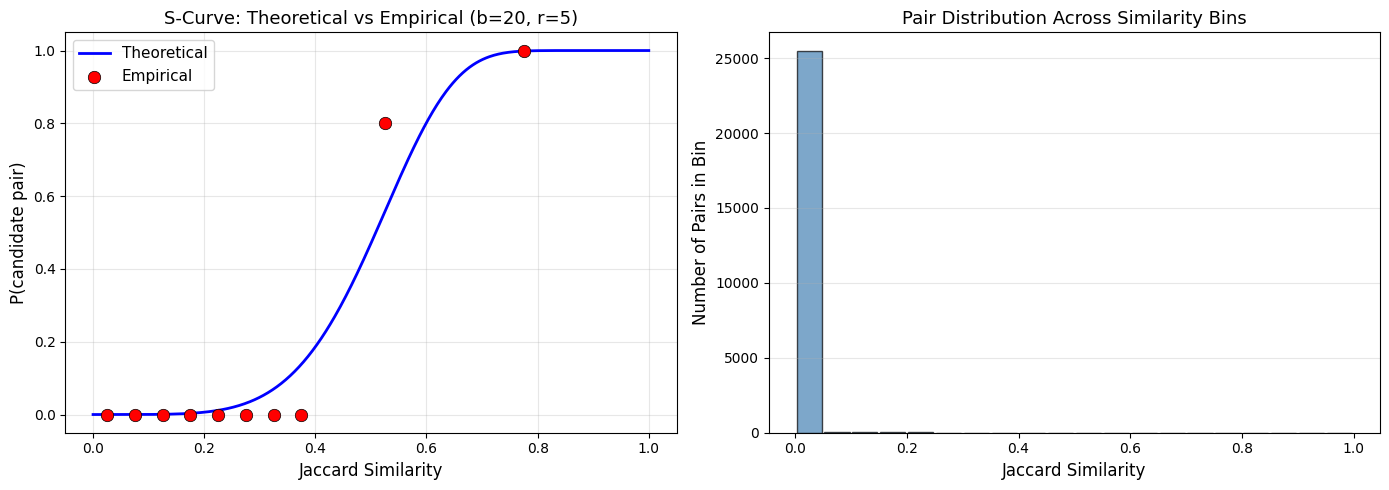

In [20]:
# --- Experimental S-curve (brute-force on small subset for accuracy) ---
print(f"Building experimental S-curve via brute-force on small subset...")

# Use a small subset where brute-force is feasible
N_SUB = 2000
sub_sigs = signatures[:N_SUB]
sub_shingles = shingle_sets[:N_SUB]
sub_candidates = lsh_find_candidates(sub_sigs)

print(f"  Subset size: {N_SUB}")
print(f"  LSH candidates in subset: {len(sub_candidates)}")
print(f"  Computing all pairwise Jaccard similarities...")

exp_pairs = []
for i in range(N_SUB):
    for j in range(i + 1, N_SUB):
        sim = jaccard_similarity(sub_shingles[i], sub_shingles[j])
        if sim > 0.01:  # Skip near-zero pairs (noise)
            is_cand = (i, j) in sub_candidates
            exp_pairs.append((sim, is_cand))

print(f"  Pairs with similarity > 0.01: {len(exp_pairs)}")

# Bin by similarity and compute empirical P(candidate)
bins = np.linspace(0, 1, 21)
bin_centers = (bins[:-1] + bins[1:]) / 2
empirical_probs = []
bin_counts = []

for k_bin in range(len(bins) - 1):
    pairs_in_bin = [(s, c) for s, c in exp_pairs if bins[k_bin] <= s < bins[k_bin + 1]]
    bin_counts.append(len(pairs_in_bin))
    if len(pairs_in_bin) >= 5:
        prob = sum(c for _, c in pairs_in_bin) / len(pairs_in_bin)
        empirical_probs.append(prob)
    else:
        empirical_probs.append(np.nan)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: S-curve comparison
s_values = np.linspace(0, 1, 500)
theoretical = [s_curve(s, NUM_BANDS, ROWS_PER_BAND) for s in s_values]
axes[0].plot(s_values, theoretical, 'b-', linewidth=2, label='Theoretical')

valid_mask = [not np.isnan(p) for p in empirical_probs]
valid_centers = [c for c, v in zip(bin_centers, valid_mask) if v]
valid_probs = [p for p, v in zip(empirical_probs, valid_mask) if v]
axes[0].scatter(valid_centers, valid_probs, c='red', s=80, zorder=5,
                edgecolors='black', linewidths=0.5, label='Empirical')

axes[0].set_xlabel('Jaccard Similarity', fontsize=12)
axes[0].set_ylabel('P(candidate pair)', fontsize=12)
axes[0].set_title(f'S-Curve: Theoretical vs Empirical (b={NUM_BANDS}, r={ROWS_PER_BAND})', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Right: Sample distribution across bins
axes[1].bar(bin_centers, bin_counts, width=0.045, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Jaccard Similarity', fontsize=12)
axes[1].set_ylabel('Number of Pairs in Bin', fontsize=12)
axes[1].set_title('Pair Distribution Across Similarity Bins', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()